1. Попередній аналіз даних

=== Огляд даних ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9888 entries, 0 to 9887
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   movie_id            9888 non-null   int64  
 1   title               9888 non-null   object 
 2   year                9888 non-null   int64  
 3   genre               9888 non-null   object 
 4   rating              9811 non-null   object 
 5   runtime_minutes     9886 non-null   float64
 6   budget              7591 non-null   float64
 7   production_company  9873 non-null   object 
 8   country             9887 non-null   object 
 9   worldwide           3665 non-null   float64
 10  domestic            3665 non-null   float64
 11  domestic_percent    3665 non-null   float64
 12  foreign             3665 non-null   float64
 13  foreign_percent     3665 non-null   float64
 14  average_rating      5330 non-null   float64
 15  number_of_votes     5330 non-null  

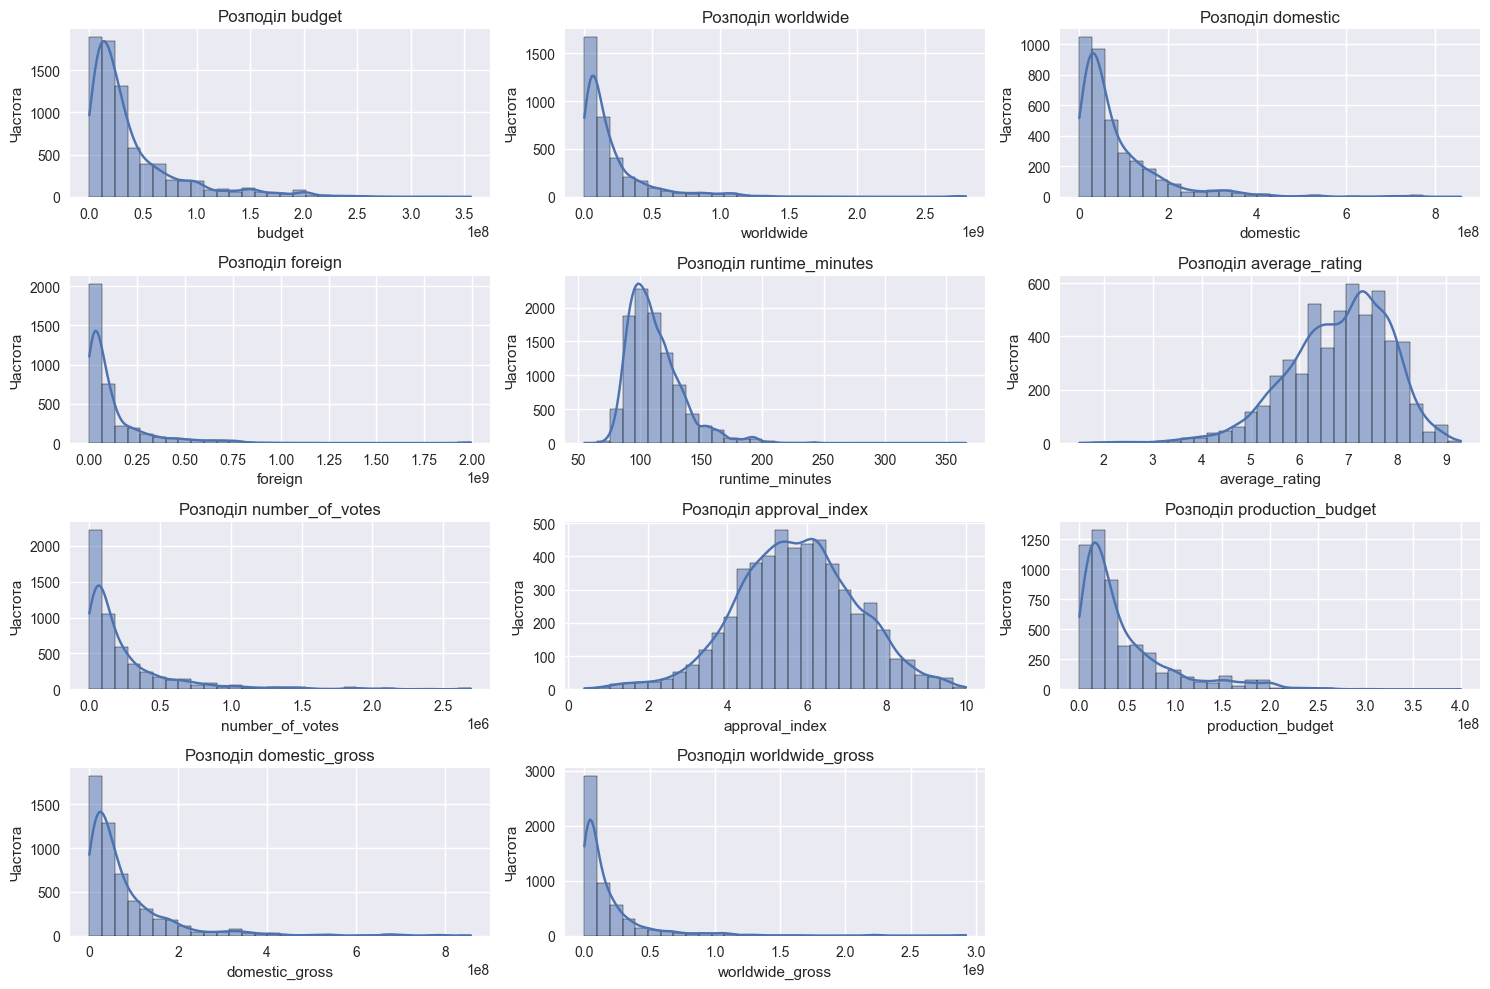

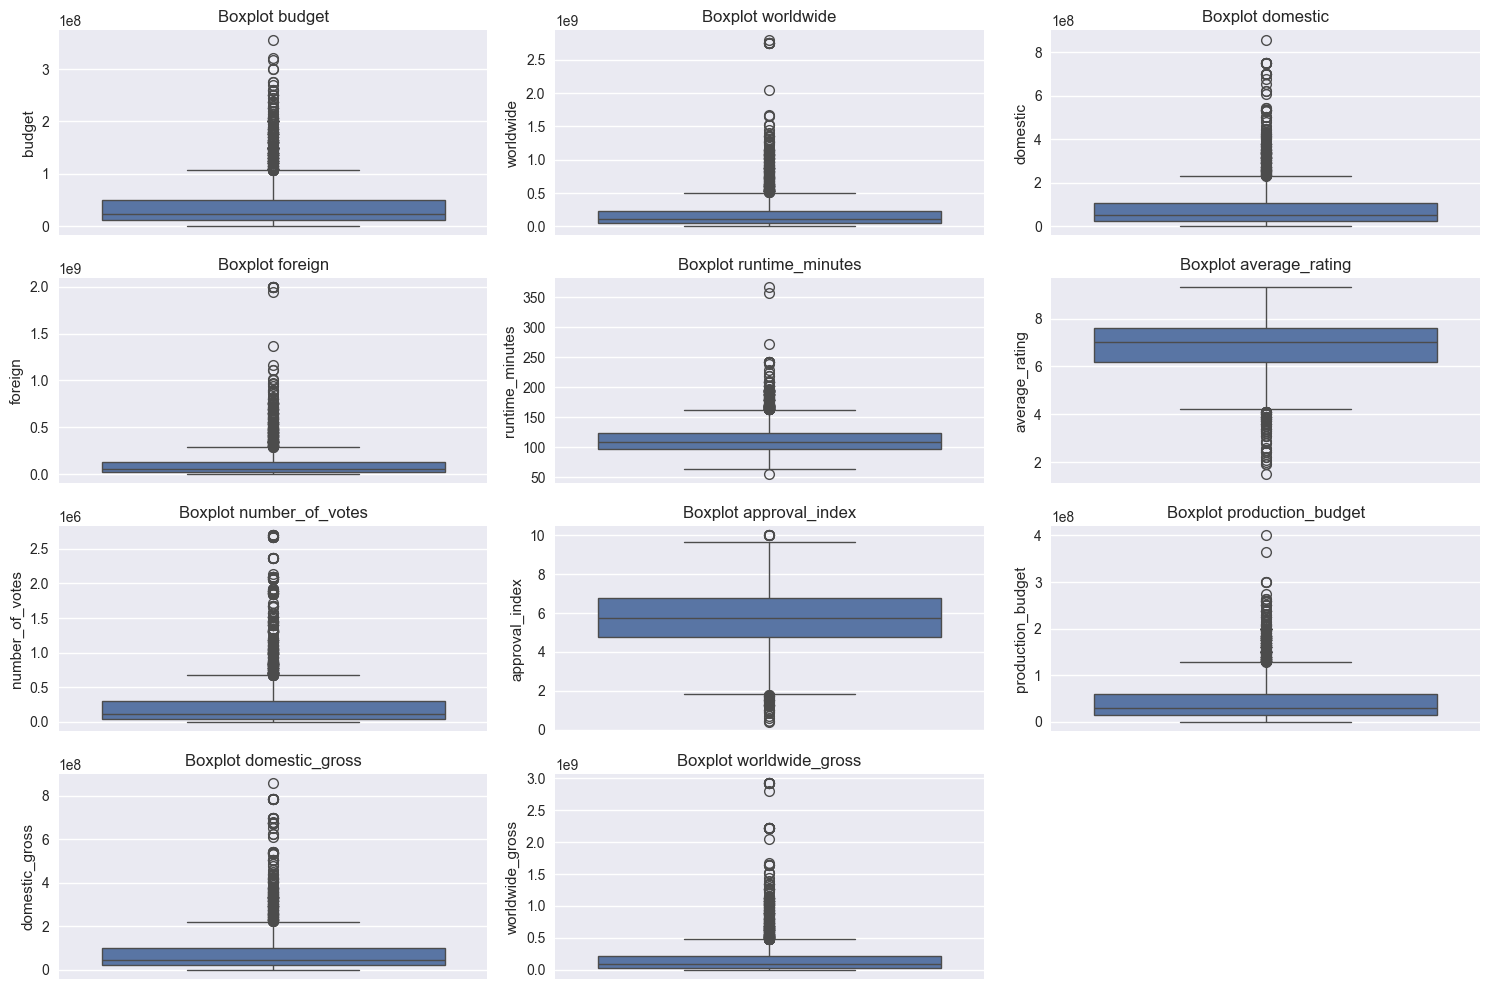

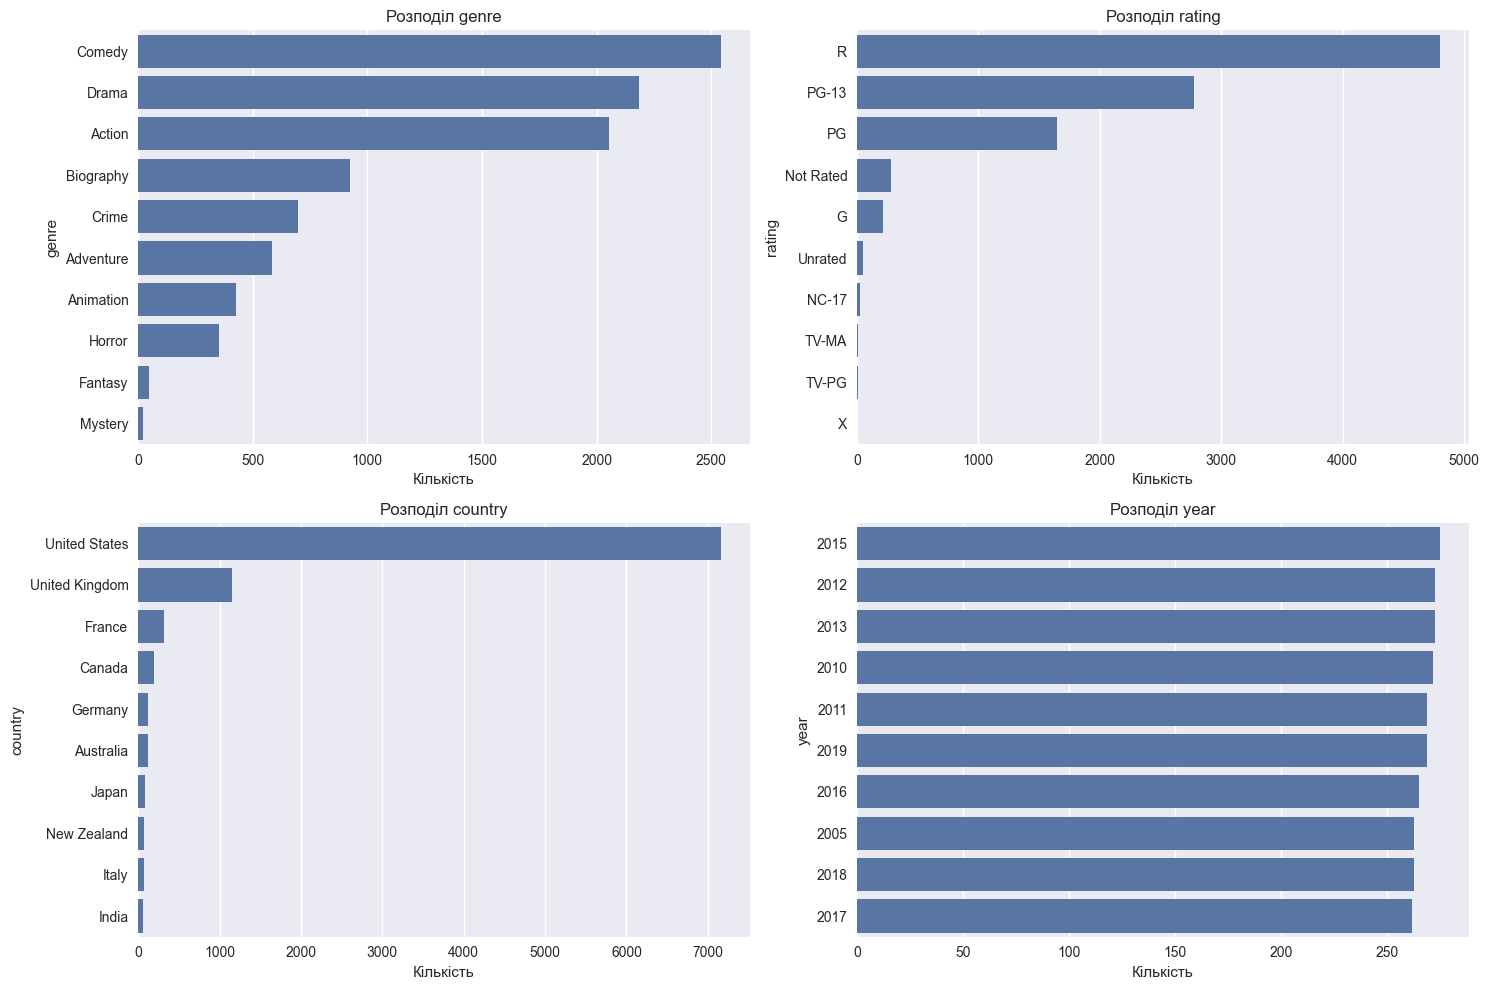

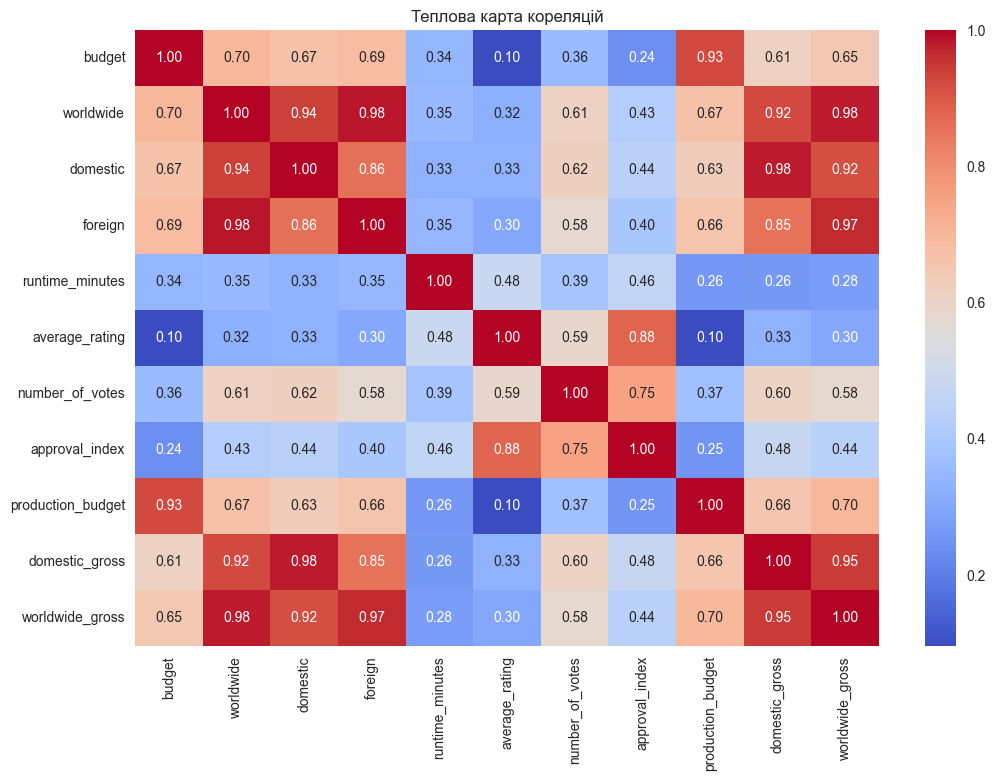

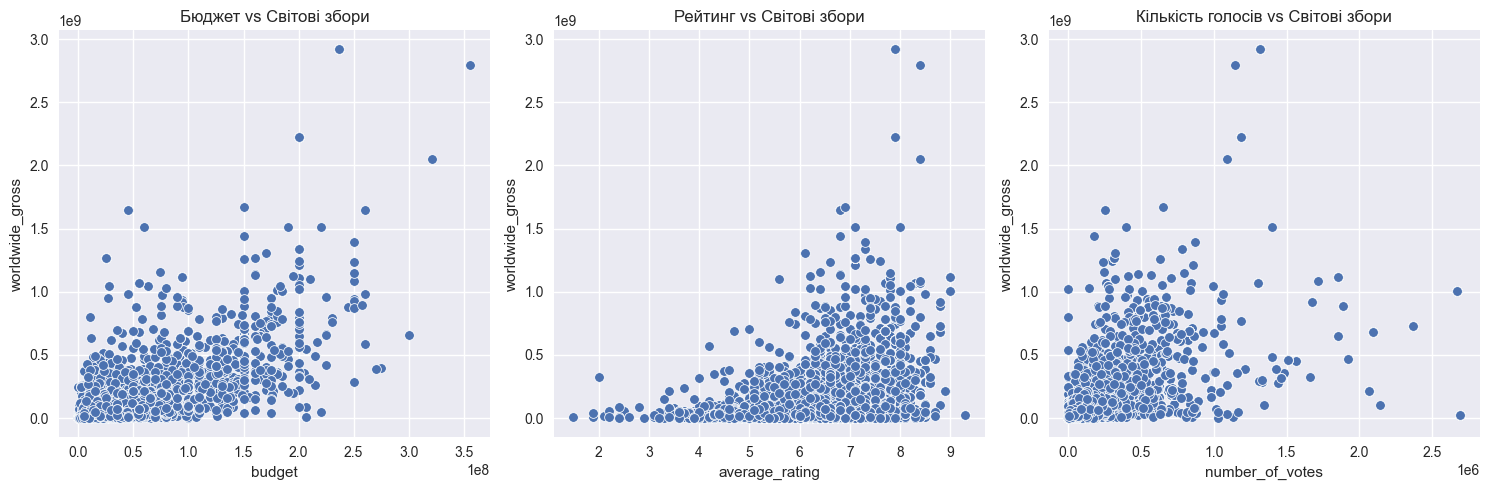


=== Відсоток пропусків ===
rating                 0.778722
runtime_minutes        0.020227
budget                23.230178
production_company     0.151699
country                0.010113
worldwide             62.934871
domestic              62.934871
domestic_percent      62.934871
foreign               62.934871
foreign_percent       62.934871
average_rating        46.096278
number_of_votes       46.096278
approval_index        46.096278
production_budget     46.096278
domestic_gross        46.096278
worldwide_gross       46.096278
dtype: float64


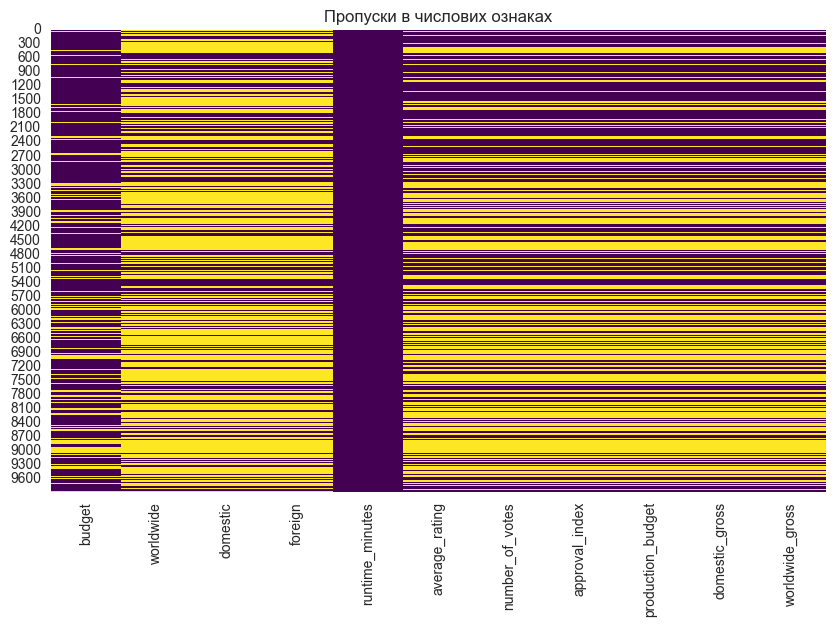

In [23]:
# Імпорт бібліотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sqlalchemy import create_engine
from db_config import CONN_STR
import warnings
warnings.filterwarnings('ignore')

# Налаштування стилю графіків
plt.style.use('seaborn-v0_8')
%matplotlib inline

# Підключення до PostgreSQL
engine = create_engine(CONN_STR)

# SQL-запит для об'єднання таблиць
query = """
SELECT 
    m.movie_id, m.title, m.year, m.genre, m.rating, m.runtime_minutes, m.budget, m.production_company, m.country,
    bo.worldwide, bo.domestic, bo.domestic_percent, bo.foreign, bo.foreign_percent,
    mp.average_rating, mp.number_of_votes, mp.approval_index, mp.production_budget, mp.domestic_gross, mp.worldwide_gross,
    CASE WHEN oa.winner IS NOT NULL THEN 1 ELSE 0 END AS oscar_nominated
FROM main.dim_movie m
LEFT JOIN main.fact_box_office bo ON m.movie_id = bo.movie_id
LEFT JOIN main.fact_movie_performance mp ON m.movie_id = mp.movie_id
LEFT JOIN main.fact_oscar_awards oa ON m.movie_id = oa.movie_id
"""

# Завантаження даних
df = pd.read_sql(query, engine)

# Огляд структури даних
print("=== Огляд даних ===")
print(df.info())
print("\n=== Перші 5 рядків ===")
print(df.head())

# 1.1 Аналіз розподілу числових ознак
numeric_cols = ['budget', 'worldwide', 'domestic', 'foreign', 'runtime_minutes', 
                'average_rating', 'number_of_votes', 'approval_index', 'production_budget', 
                'domestic_gross', 'worldwide_gross']
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(4, 3, i)
    sns.histplot(df[col].dropna(), bins=30, kde=True)
    plt.title(f'Розподіл {col}')
    plt.xlabel(col)
    plt.ylabel('Частота')
plt.tight_layout()
plt.show()

# Boxplot для виявлення викидів
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(y=df[col].dropna())
    plt.title(f'Boxplot {col}')
plt.tight_layout()
plt.show()

# 1.1 Аналіз розподілу категоріальних ознак
categorical_cols = ['genre', 'rating', 'country', 'year']
plt.figure(figsize=(15, 10))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(2, 2, i)
    sns.countplot(y=df[col], order=df[col].value_counts().index[:10])
    plt.title(f'Розподіл {col}')
    plt.xlabel('Кількість')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

# 1.2 Кореляційний аналіз
plt.figure(figsize=(12, 8))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Теплова карта кореляцій')
plt.show()

# Діаграми розсіювання для ключових пар
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.scatterplot(x='budget', y='worldwide_gross', data=df)
plt.title('Бюджет vs Світові збори')
plt.subplot(1, 3, 2)
sns.scatterplot(x='average_rating', y='worldwide_gross', data=df)
plt.title('Рейтинг vs Світові збори')
plt.subplot(1, 3, 3)
sns.scatterplot(x='number_of_votes', y='worldwide_gross', data=df)
plt.title('Кількість голосів vs Світові збори')
plt.tight_layout()
plt.show()

# 1.3 Аналіз пропусків
print("\n=== Відсоток пропусків ===")
missing = df.isnull().mean() * 100
print(missing[missing > 0])

# Візуалізація пропусків
plt.figure(figsize=(10, 6))
sns.heatmap(df[numeric_cols].isnull(), cbar=False, cmap='viridis')
plt.title('Пропуски в числових ознаках')
plt.show()

2. Підготовка даних

In [24]:


# Припускаємо, що df уже завантажено
# 1. Обробка пропусків
# Категоріальні колонки
df['rating'].fillna('R', inplace=True)
df['production_company'].fillna('Unknown', inplace=True)
df['country'].fillna('United States', inplace=True)

# Числові колонки
df['runtime_minutes'].fillna(df['runtime_minutes'].median(), inplace=True)
df['budget'].fillna(df['budget'].median(), inplace=True)

# 2. Кодування категоріальних ознак
# One-hot encoding для genre та rating
df = pd.get_dummies(df, columns=['genre', 'rating'], prefix=['genre', 'rating'])

# Для country: топ-5 країн, решта — 'Other'
top_countries = ['United States', 'United Kingdom', 'France', 'Canada', 'Germany']
df['country'] = df['country'].apply(lambda x: x if x in top_countries else 'Other')
df = pd.get_dummies(df, columns=['country'], prefix='country')

# 3. Вибір ознак
features = ['year', 'runtime_minutes', 'budget'] + \
           [col for col in df.columns if col.startswith('genre_') or 
            col.startswith('rating_') or col.startswith('country_')]

# 4. Дані для регресії
df_reg = df[df['worldwide_gross'].notnull()]
X_reg = df_reg[features]
y_reg = df_reg['worldwide_gross']
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# 5. Дані для класифікації
X_class = df[features]
y_class = df['oscar_nominated']
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42
)

print("Дані підготовлено для моделювання.")

Дані підготовлено для моделювання.


3. Моделювання

=== Регресія ===
Лінійна регресія:
MSE: 39731296871736072.00, R²: 0.45
Random Forest Regressor:
MSE: 15421971642688486.00, R²: 0.79
XGBoost Regressor:
MSE: 19117421903045784.00, R²: 0.74

=== Класифікація ===
Логістична регресія:
Accuracy: 0.79, F1-score: 0.64, ROC-AUC: 0.84
Random Forest Classifier:
Accuracy: 0.91, F1-score: 0.87, ROC-AUC: 0.95
XGBoost Classifier:
Accuracy: 0.88, F1-score: 0.82, ROC-AUC: 0.93


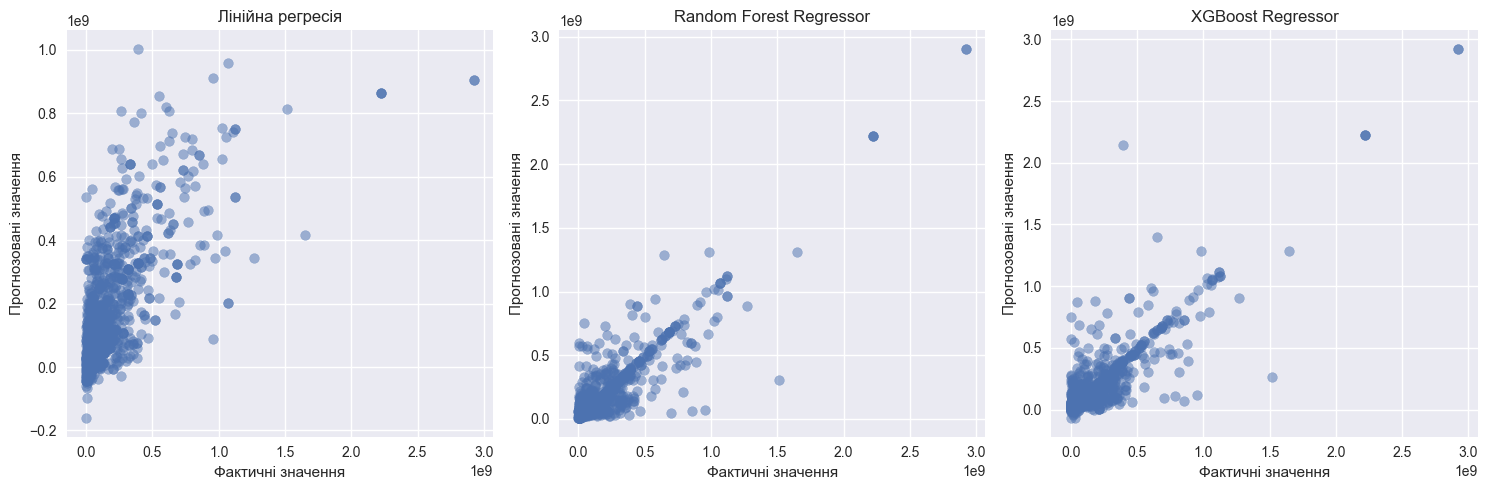

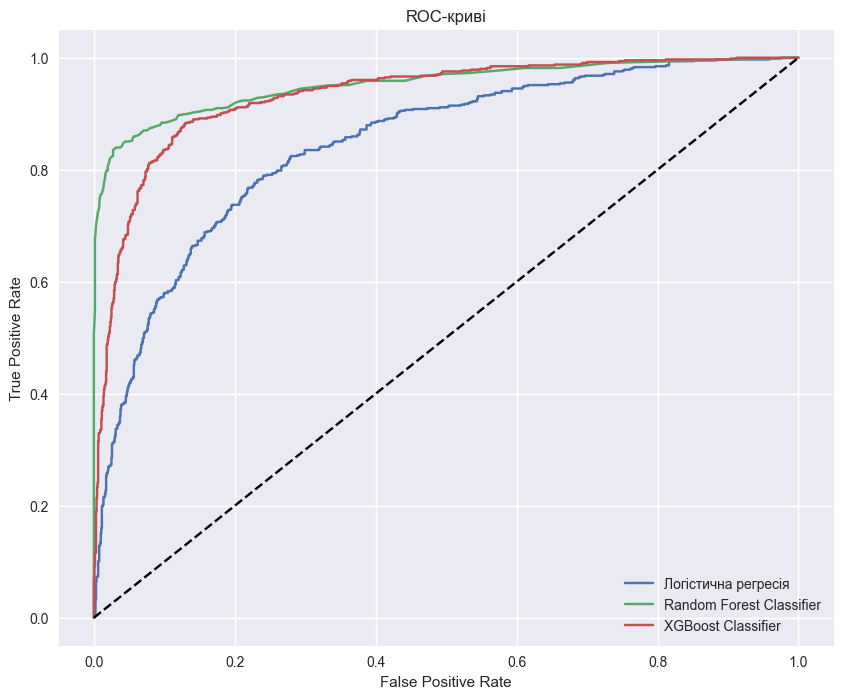

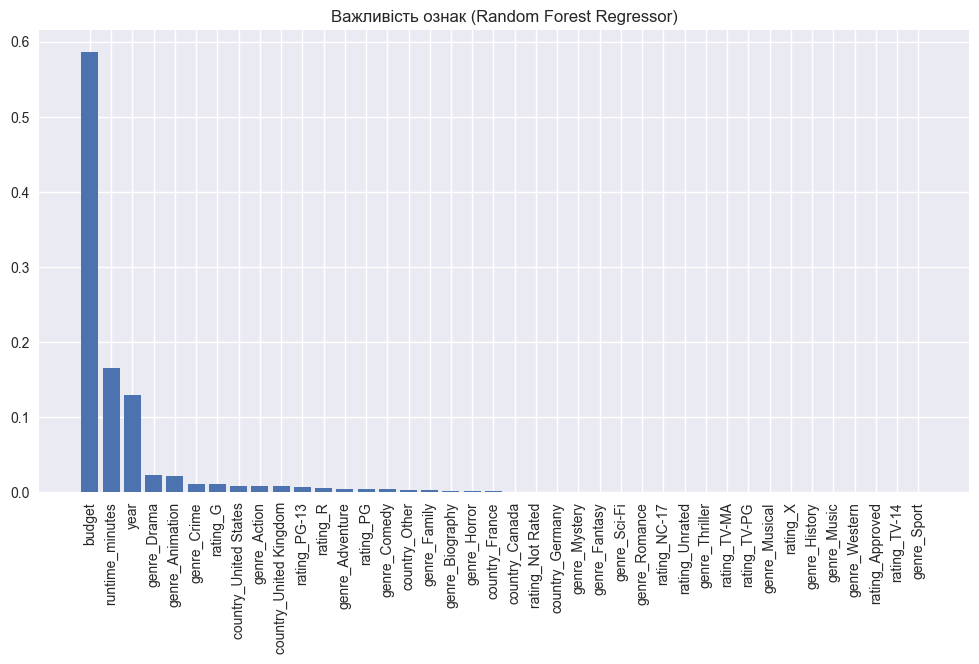

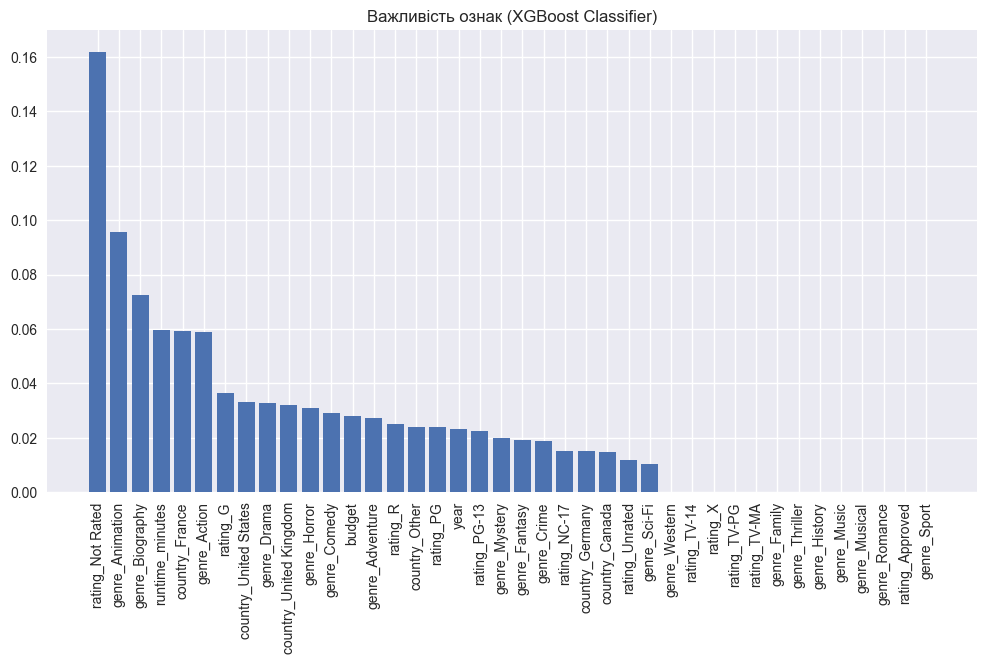

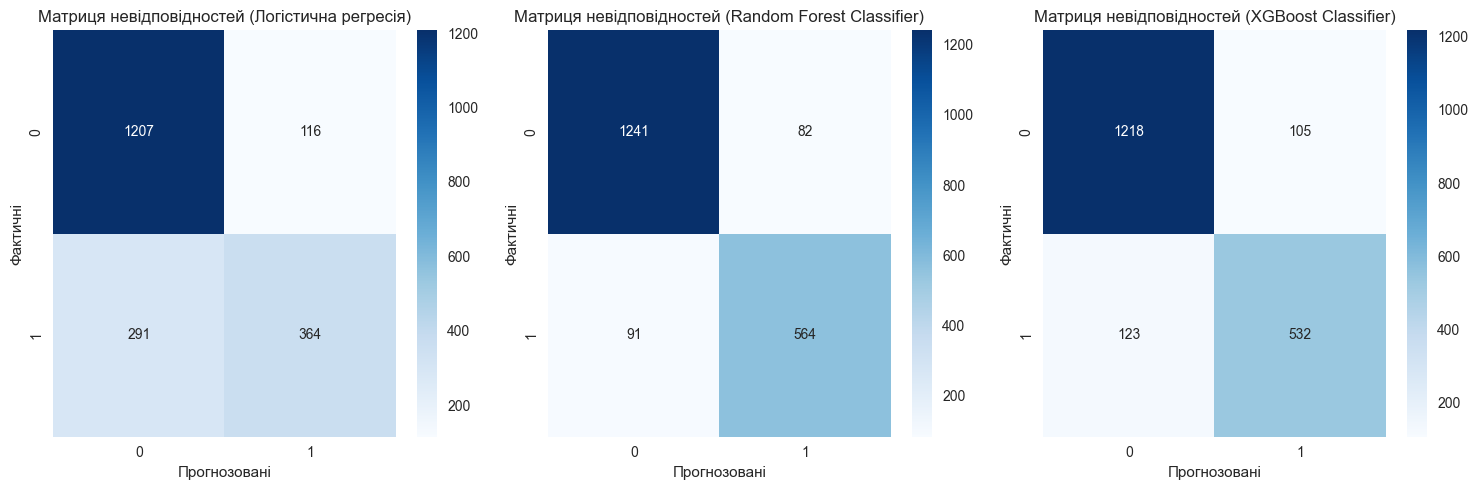

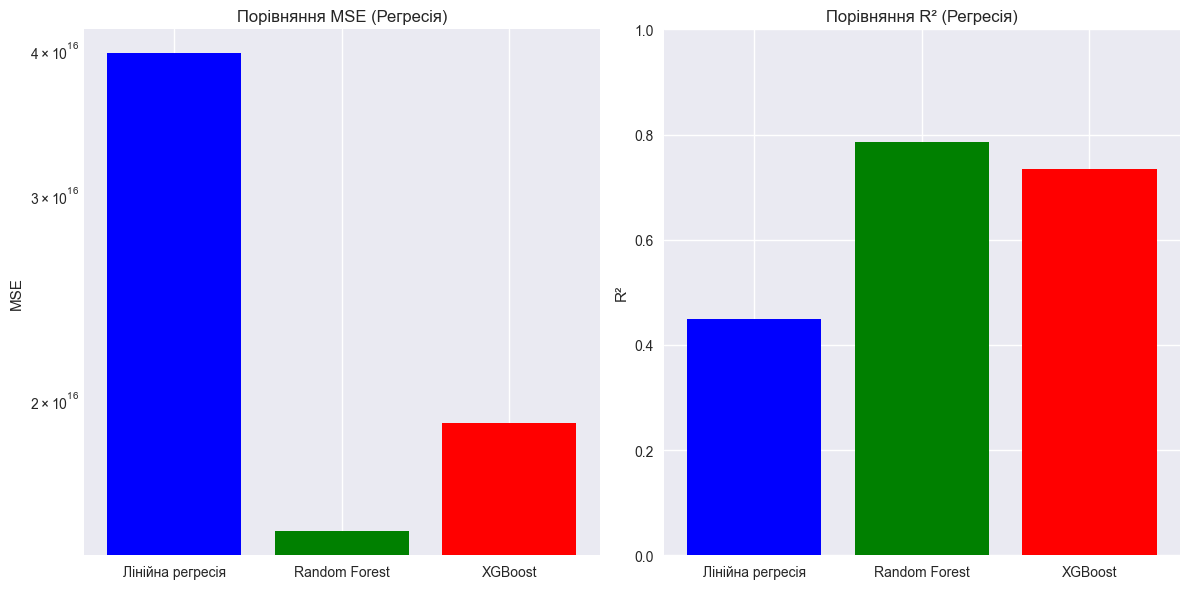

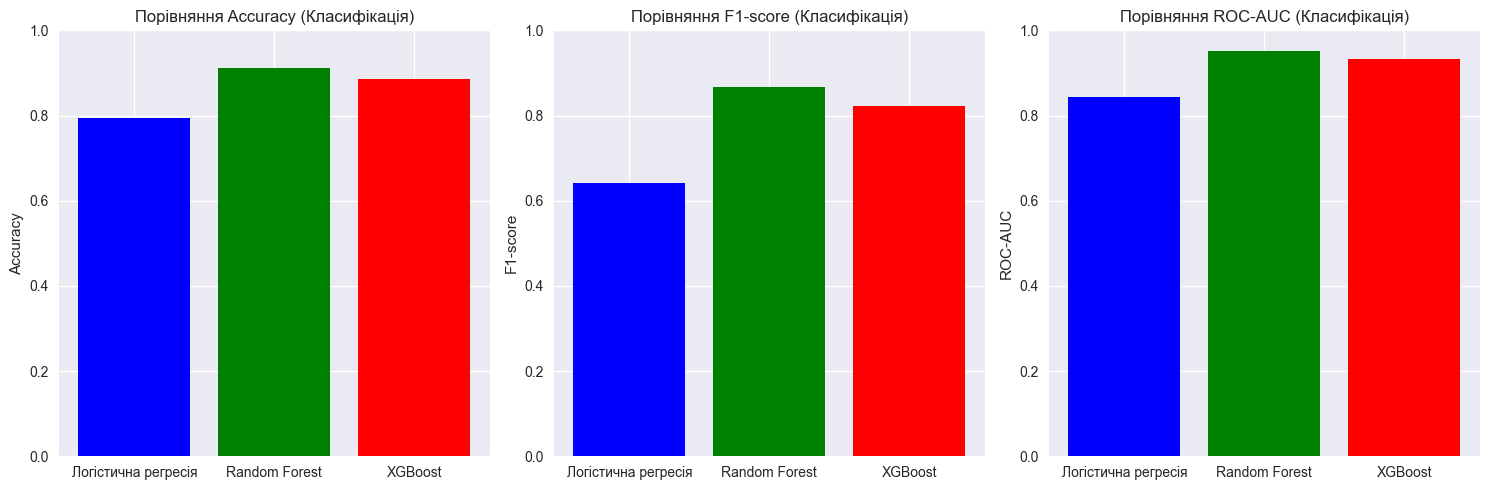

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
import xgboost as xgb

# Масштабування числових ознак
scaler = StandardScaler()
numeric_features = ['year', 'runtime_minutes', 'budget']
X_train_reg[numeric_features] = scaler.fit_transform(X_train_reg[numeric_features])
X_test_reg[numeric_features] = scaler.transform(X_test_reg[numeric_features])
X_train_class[numeric_features] = scaler.fit_transform(X_train_class[numeric_features])
X_test_class[numeric_features] = scaler.transform(X_test_class[numeric_features])

# Функція для оцінки регресійних моделей
def evaluate_regression_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f'MSE: {mse:.2f}, R²: {r2:.2f}')
    return y_pred, mse, r2

# Функція для оцінки класифікаційних моделей
def evaluate_classification_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    print(f'Accuracy: {accuracy:.2f}, F1-score: {f1:.2f}, ROC-AUC: {roc_auc:.2f}')
    return y_pred, y_pred_proba, accuracy, f1, roc_auc

# Моделі для регресії
print('=== Регресія ===')
lin_reg = LinearRegression()
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
xgb_reg = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)

print('Лінійна регресія:')
y_pred_lin_reg, mse_lin_reg, r2_lin_reg = evaluate_regression_model(lin_reg, X_train_reg, y_train_reg, X_test_reg, y_test_reg)
print('Random Forest Regressor:')
y_pred_rf_reg, mse_rf_reg, r2_rf_reg = evaluate_regression_model(rf_reg, X_train_reg, y_train_reg, X_test_reg, y_test_reg)
print('XGBoost Regressor:')
y_pred_xgb_reg, mse_xgb_reg, r2_xgb_reg = evaluate_regression_model(xgb_reg, X_train_reg, y_train_reg, X_test_reg, y_test_reg)

# Моделі для класифікації
print('\n=== Класифікація ===')
log_reg = LogisticRegression(max_iter=1000)
rf_class = RandomForestClassifier(n_estimators=100, random_state=42)
xgb_class = xgb.XGBClassifier(objective='binary:logistic', n_estimators=100, random_state=42)

print('Логістична регресія:')
y_pred_log_reg, y_pred_proba_log_reg, acc_log_reg, f1_log_reg, roc_auc_log_reg = evaluate_classification_model(log_reg, X_train_class, y_train_class, X_test_class, y_test_class)
print('Random Forest Classifier:')
y_pred_rf_class, y_pred_proba_rf_class, acc_rf_class, f1_rf_class, roc_auc_rf_class = evaluate_classification_model(rf_class, X_train_class, y_train_class, X_test_class, y_test_class)
print('XGBoost Classifier:')
y_pred_xgb_class, y_pred_proba_xgb_class, acc_xgb_class, f1_xgb_class, roc_auc_xgb_class = evaluate_classification_model(xgb_class, X_train_class, y_train_class, X_test_class, y_test_class)

# Візуалізація для регресії
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.scatter(y_test_reg, y_pred_lin_reg, alpha=0.5)
plt.xlabel('Фактичні значення')
plt.ylabel('Прогнозовані значення')
plt.title('Лінійна регресія')
plt.subplot(1, 3, 2)
plt.scatter(y_test_reg, y_pred_rf_reg, alpha=0.5)
plt.xlabel('Фактичні значення')
plt.ylabel('Прогнозовані значення')
plt.title('Random Forest Regressor')
plt.subplot(1, 3, 3)
plt.scatter(y_test_reg, y_pred_xgb_reg, alpha=0.5)
plt.xlabel('Фактичні значення')
plt.ylabel('Прогнозовані значення')
plt.title('XGBoost Regressor')
plt.tight_layout()
plt.show()

# Візуалізація для класифікації (ROC-криві)
plt.figure(figsize=(10, 8))
fpr, tpr, _ = roc_curve(y_test_class, y_pred_proba_log_reg)
plt.plot(fpr, tpr, label='Логістична регресія')
fpr, tpr, _ = roc_curve(y_test_class, y_pred_proba_rf_class)
plt.plot(fpr, tpr, label='Random Forest Classifier')
fpr, tpr, _ = roc_curve(y_test_class, y_pred_proba_xgb_class)
plt.plot(fpr, tpr, label='XGBoost Classifier')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-криві')
plt.legend()
plt.show()

# Важливість ознак для Random Forest Regressor
importances = rf_reg.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(12, 6))
plt.title('Важливість ознак (Random Forest Regressor)')
plt.bar(range(X_train_reg.shape[1]), importances[indices], align='center')
plt.xticks(range(X_train_reg.shape[1]), X_train_reg.columns[indices], rotation=90)
plt.show()

# Важливість ознак для XGBoost Classifier
importances = xgb_class.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(12, 6))
plt.title('Важливість ознак (XGBoost Classifier)')
plt.bar(range(X_train_class.shape[1]), importances[indices], align='center')
plt.xticks(range(X_train_class.shape[1]), X_train_class.columns[indices], rotation=90)
plt.show()

# Матриці невідповідностей для класифікації
plt.figure(figsize=(15, 5))
cm_log_reg = confusion_matrix(y_test_class, y_pred_log_reg)
plt.subplot(1, 3, 1)
sns.heatmap(cm_log_reg, annot=True, fmt='d', cmap='Blues')
plt.title('Матриця невідповідностей (Логістична регресія)')
plt.xlabel('Прогнозовані')
plt.ylabel('Фактичні')
cm_rf_class = confusion_matrix(y_test_class, y_pred_rf_class)
plt.subplot(1, 3, 2)
sns.heatmap(cm_rf_class, annot=True, fmt='d', cmap='Blues')
plt.title('Матриця невідповідностей (Random Forest Classifier)')
plt.xlabel('Прогнозовані')
plt.ylabel('Фактичні')
cm_xgb_class = confusion_matrix(y_test_class, y_pred_xgb_class)
plt.subplot(1, 3, 3)
sns.heatmap(cm_xgb_class, annot=True, fmt='d', cmap='Blues')
plt.title('Матриця невідповідностей (XGBoost Classifier)')
plt.xlabel('Прогнозовані')
plt.ylabel('Фактичні')
plt.tight_layout()
plt.show()

# Порівняння моделей: Стовпчасті діаграми для регресії
plt.figure(figsize=(12, 6))
models_reg = ['Лінійна регресія', 'Random Forest', 'XGBoost']
mse_values = [mse_lin_reg, mse_rf_reg, mse_xgb_reg]
r2_values = [r2_lin_reg, r2_rf_reg, r2_xgb_reg]

plt.subplot(1, 2, 1)
plt.bar(models_reg, mse_values, color=['blue', 'green', 'red'])
plt.title('Порівняння MSE (Регресія)')
plt.ylabel('MSE')
plt.yscale('log')  # Логарифмічна шкала для кращої видимості

plt.subplot(1, 2, 2)
plt.bar(models_reg, r2_values, color=['blue', 'green', 'red'])
plt.title('Порівняння R² (Регресія)')
plt.ylabel('R²')
plt.ylim(0, 1)  # Обмеження до діапазону [0, 1] для R²
plt.tight_layout()
plt.show()

# Порівняння моделей: Стовпчасті діаграми для класифікації
plt.figure(figsize=(15, 5))
models_class = ['Логістична регресія', 'Random Forest', 'XGBoost']
acc_values = [acc_log_reg, acc_rf_class, acc_xgb_class]
f1_values = [f1_log_reg, f1_rf_class, f1_xgb_class]
roc_auc_values = [roc_auc_log_reg, roc_auc_rf_class, roc_auc_xgb_class]

plt.subplot(1, 3, 1)
plt.bar(models_class, acc_values, color=['blue', 'green', 'red'])
plt.title('Порівняння Accuracy (Класифікація)')
plt.ylabel('Accuracy')
plt.ylim(0, 1)

plt.subplot(1, 3, 2)
plt.bar(models_class, f1_values, color=['blue', 'green', 'red'])
plt.title('Порівняння F1-score (Класифікація)')
plt.ylabel('F1-score')
plt.ylim(0, 1)

plt.subplot(1, 3, 3)
plt.bar(models_class, roc_auc_values, color=['blue', 'green', 'red'])
plt.title('Порівняння ROC-AUC (Класифікація)')
plt.ylabel('ROC-AUC')
plt.ylim(0, 1)

plt.tight_layout()
plt.show()